# Kapitel 2:



## Faktafrågor:

---

### Uppgift 1.
 De sju stegen är följande: 
Steg 1: Definiera problemet och skapa en helhetsbild.
Steg 2: Få tillgång till datan.
Steg 3: Utforska datan, gör en EDA.
Steg 4: Bearbeta datan.
Steg 5: ML-modellering.
Steg 6: Presentera din lösning för intressenter.
Steg 7: Produktionssättning av modellen och övervakning av implementeringen.

Man arbetar med dessa steg iterativt, alltså man måste jobba fram och tillbaka. För först har man en ide sedan tar man steg 2, men om ens idé ej stämmer överens med steg 2 måste man hoppa tillbaka till steg 1. Detta gäller alla steg.

### Uppgift 2. 
Om man lyckas skapa en modell och faktiskt ska produktionssätta den så kan följande vara bra att tänka på: 
Exempelvis kan vi skapa olika enhetstester för att funktionaliteten är som den ska vara. 
Det är en god idé att bevaka modellens prestanda eftersom modeller kan bli sämre med tiden, exempel för att datan ser annorlunda ut till följd av förändringar inom innovation, ekonomi och beteende hos människor.

### Uppgift 3.
 scikit_learn är ett populärt **Python-bibliotek för Machine Learning**. Det innehåller färdiga verktyg för bland annat:
- Regression
- KLassificering
- Clustering
- Feature engineering
- Data preprocessing
- Modellval
- Cross-validation
- Hyperparameter tuning

Exempelvis kan man använda DescisionTreeRegressor, RandomForestClassifier, StandardScaler och GridSearchCV utan att behöva implementer algoritmerna från grunden.

--- 

### Scikit-learns centrala designprinciper
Scikit-learn försöker ha ett enkelt och koskevent API. Det innebär att olika ML-verkyg fungerar på ungefär samma sätt. 
Några centrala principer är:

1. #### Consistency - konsekvens
Olika objekt använder samma typ av gränssnitt.
Exemplevis:
model.fit(X_train, y_train)

används för att träna många olika modeller.

Det gör att vi relativt enkelt kan byta:
DecisionTreeRegressor()
mot exempelvis:
RandomForestRegressor()
utan att hela koden behöver skrivas om.

2. #### Inspection - inspekterbarhet
Parametrar ska vara lätta att se och ändra
Exempel: 
model = DecisionTreeRegressor(max_depth=5)
Man kan sedan exempelvis använda:
model.get_params()
för att se modellens parametrar.

---

3. #### Non-proliferation of classes
Scikit-learn försöker undvika att skapa en massa olika specialklasser för samma typ av problem.

Istället används ett relativt litet antal generella och återanvändbara koncept.

--- 

4. #### Compostion - komposition
Olika komponenter kan kombineras.

Det är exempelvis möjligt att skapa en pipeline:
Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
Här kombineras preprocessing och ML-modellen till ett sammanhängandeflöde.

---

5. #### Sensible defaults
Många parametrar har rimliga standardvärden, så att man kan komma igång utan att behöva konfigurera allting.

---

### Estimators
En estimator är ett objekt som kan lära sig något från data.

Det centrala är metoden:

fit()

Exempel:
En estimator är ett objekt som kan lära sig något från data.

Det centrala är metoden:

fit()

Exempel:
model = DecisionTreeRegressor()

model.fit(X_train, y_train)

DecisionTreeRegressor är alltså en estimator.

Andra exempel:
LinearRegression()
RandomForestRegressor()
LogisticRegression()
StandardScaler()

Det viktiga är: 
**Estimator -> har** fit() och lär sig från data.

--- 

### Predictors
En predictor är en estimator som dessutom kan göra förutsägelser.
Den har metoden:
predict()
Exempel:
model.fit(X_train, y_train)

predictions = model.predict(X_test)

Exempel på predictors:
- LinearRegression
- DecisionTreeRegressor
- RandomForestRegressor
- LogisticRegression
- KNeighborsClassifier

En predictor kan alltså lära sig och sedan göra förutsägelser.

---

### Transformers
En transformer använda för att transformera data.
Den har framför allt:
fit()
tranform()

Exempelvis:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

StandardScaler lär sig först hur träningsdatan ser ut, exemepvis dess medelvärde och standardavvikesle.

Sedan använder den informantionen för att transformera datan.
Det finns också:
fit_tranform()
som kombinerar de två stegn.
Exempel:
X_train_scaled = scaler.fit_transform(X_train)

---

### Uppgift 4.
 Tensorflow och Keras är verktyg för att bygga och träna framför allt neurala nätverk och Deep Learning-modeller. De använda alltså på en annan nivå än exempelvis scikit-learn.

### TensorFlow
**TensorFlow** är ett open-source ramverk för numeriska beräkningar och maskininlärning, utvecklat av Google.

Det används bland annat för:
- Neurala nätverk
- Deep Learning
- Bildklassificering
- NLP 
- Time-series-modeller
- Träning på GPU/TPU

TensorFlow arbetar mycket med tensorer - flerdimensionella numeriska datastrukturer.

Exempel: 
scalar       → 5
vector      → [1, 2, 3]
matrix      → [[1, 2], [3, 4]]
tensor      → flera dimensioner

Namnet TensorFlow kommer alltså från att data representeras som tensors som "flödar" genom beräkningar.

---

### Keras
**Keras** är ett högnivå-API för Deep Learning som gör det mycket enklare att bygga neurala nätverk.
I modern TensorFlow används Keras som det användarvänliga gränssnittet:
import tensorflow as tf
from tensorflow import keras

Man kan exempelvis skapa ett neuralt nätverk ganska enkelt:
model = keras.Sequential([
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1)
])

Sedan kan modellen konfigureras:
model.compile(
    optimizer="adam",
    loss="mse"
)
och tränas:
model.fit(X_train, y_train, epochs=10)

---
### Hur hänger TensorFlow och Keras ihop?
Deep Learning -> TensorFlow -> Keras -> Neurala nätverk
Men det är lite mer korrekt att säga att Keras är ett högnivå-API som kan användas ovanpå olika backend-motorer, där TensorFlow är en av dem. Keras 3 kan bland annat använda TensorFlow, JAX eller PyTorch som backend.

---

## Resonemangfrågor

--- 


### Uppgift 5. 
Stina har rätt. Kalle gör ett vanligt men viktigt misstag inom maskininlärning.

Testdatan ska användas för den slutliga, opartiska utvärderingen av modellen. Om Kalle tittar på testresultatet, ändrar modellen och sedan testar igen, använder han i praktiken testdatan för att optimera modellen.

Processen blir då ungefär:
Träna modell -> Testa på testdata -> "Resultatet är inte bra nog" -> Ändra modellen -> Testa igen -> "Ändra lite till..." -> Testa igen

Efter många sådana iterationer kan modellen bli anpassad till just testdatan, även om Kalle aldrig direkt tränar modellen på testexemplen. Det är en form av överanpassning (overfitting).

Hur bör man göra istället?

Man bör ha en separat valideringsdata för att justera modellen
Man kan exempelvis använda GridSearchCV på träningsdatan för att hitta bra hyperparametrar. När man sedan är nöjd med modellen använder man testdatan en gång i slutet för att få en så rättvis uppskattning som möjligt av hur modellen kommer prestera på tidigare osedd data.

### Uppgift 6.
 Det finns många orsaker till att AI/ML-projekt inte når sina ursprungliga mål eller aldrig kommer längre än en prototyp. Ofta är problemet inte själva ML-algoritmen, utan data, affärsnytta, organisation och implementation.

#### Vanliga orsaker
1. **Dålig eller otillräcklig data**

En ML-modell är beroende av bra data.

Problemen kan vara:
- För lite data
- Saknade värden
- Felaktig data
- Skev eller biased data
- Data som inte representerar verkligheten
- Dålig datakvalitet

Om datan är dålig hjälper det sällan att bara välja en mer avancerad algoritm.
  "Shit in, Shit out"

---

2. **Otydligt problem**
Ibland börjar projektet med:
"Vi ska använda AI!"
i stället för:
"Vilket konkret problem ska vi lösa?"
AI är ett verktyg, inte ett mål i sig.

Ett projekt bör börja med frågor som:
- Vilket problem försöker vi lösa?
- Kan ML faktiskt lösa det?
- Hur mäter vi framgång?
- Är en vanlig regelbaserad lösning tillräcklig?

---

3. **Orealistiska förväntningar**
AI kan låta väldigt kraftfullt, vilket ibland leder till för höga förväntningar.

Man kanske förväntar sig:
100 % accuracy -> Perfekta predictions -> Full automation -> Ingen mänsklig kontroll

Men verkligheten innehåller osäkerhet, brus och förändringar.

En modell med exempelvis 85 % accuracy kan vara fantastisk i ett problem men helt oanvändbar i ett annat.

Det beror på konsekvensen av fel.

--- 

4. **Prototypen fungear, men inte i produktion**
Detta är ett mycket vanligt problem.

En modell kan fungera perfekt i en Jupyter Notebook:
Notebook -> Ladda CSV -> Träna modell -> Bra accuracy

Men i produktion behöver man också hantera:
- API:er
- Datapipelines
- Säkerhet
- Skalning
- Latens
- Logging
- Övervakning
- Modelluppdateringar
- Drift och deployment

Detta är en stor del av det som ofta kalla MLOps.
En fungerade modell är alltså inte samma sak som en fungerande AI-produkt.

---

5. **Data drift och förändrad verklighe**
Verklighetn förändras
En modell kanske tränades på data från 2024-2025:
Historisk data -> ML-modell -> Bra resultat

Men sedan förändras exempelvis:
- Kundbeteenden
- Marknaden
- Ekonomin
- Produkter
- Sensorer
- Användarbeteenden

Då kan modellen gradvis bli sämre.
Det kallas ofta data drift och concept drift.

---

6. **ML är kanske inte rätt lösning**
Alla problem behöver inte AI eller ML
Exempel:
Om temperaturen > 100°C -> stäng av maskinen

Här behövs sannolikt ingen avancerad ML-modell
En viktig fråga är därför:

Ger ML tillräckligt mycket extra värde för att motivera komplexiteten?

Det kopplar till principle of parsimony: använd inte en mer komplex lösning än problemet kräver.

--- 

#### Hur bör vi förhålla oss till detta?
Jag tycker att man ska vara realistisk och experimentell.

Ett AI/ML-projekt bör ses som en process där man testar hypoteser:
Problem -> Kan ML lösa det? -> Finns tillräckligt bra data? -> Bygg enkel baseline -> Förbättra eller avsluta -> Prototyp -> Produktion -> Övervaka modellen

Det är viktigt att börja med en enkel baseline. Om en enkel modell fungerar tillräckligt bra kanske ett stort Deep Learning-system inte behövs.

Man bör också acceptera att:

Att ett ML-projekt misslyckas kan vara ett värdefullt resultat.

Om man tidigt upptäcker att datan inte räcker eller att ML inte skapar tillräckligt affärsvärde kan man undvika att lägga enorma resurser på fel projekt.

---

## Koduppgifter

### Uppgift 7
Demonstration av joblib:

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import joblib

x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

joblib.dump(model, 'our_linear_model.pk1')
print("Model saved!")

loaded_model = joblib.load('our_linear_model.pk1')
print("Model loaded!")

prediction = loaded_model.predict([x_test[5]])
print(f"Predcited value: {prediction}")

### Ett kodexempel från början till slut - Huspriser i Kalifornien

1. Förstå problemet och skapa en helhetsbild 
2. Få tillgång till datan
3. EDA
4. Databearbetning
5. ML-modellering
6. Presentera din lösning för intressenter
7. Produktionssättning av modellen och övervakning av implementeringen 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Vi laddar nu in datan och inspekterar den.
housing_original = pd.read_csv("housing.csv")

# Genom att använda .info() metoden får vi en koncis summering av datan.
housing_original.info()

# Vi gör två separata utskrifter eftersom samtliga kolumner av uttrymmes skäl inte får plats enligt boken.
housing_original.iloc[:, :6].head()

housing_original.iloc[:, 5:].head()

# Från de fem första raderna i datan ovan är samtliga värden för kolumnen ocean_proximity = NEAR BAY. För att se om de finns fler kategorier och vilka dessa i sådana fall är kan vi anvönda metoden value_counts()
housing_original['ocean_proximity'].value_counts()

# Vi ser att kategorin ISLAND endast har fem stycken observationer. För att göra våra analyser mer koncisa kommer vi ta bort de rader som har värder ISLAND för kolumnen ocean_proximity
housing = housing_original[housing_original['ocean_proximity'] != 'ISLAND']
housing['ocean_proximity'].value_counts()

# Vi vet från Avsnitt 1.3.6 att kategorisk data generellt sett behöver omvandlas för att kunna använda i maskininlärningsmodeller. Genom att använda metoden .get_dummies() genomför vi one-hot-encoding och får fyra dummyvariabler eftersom vi har de fyra kategorierna <1H Ocean, INLAND, NEAR OCEAN och NEAR BAY
housing = pd.get_dummies(housing, columns = ['ocean_proximity'], dtype = int, prefix = 'dmy')

# Vi använder prefixet "dmy" för de dummyvariabler vi skapar. I nästa kodblock ser vi hur dummyvariabel-kolumnerna får namn dmy_xxx. 
housing.iloc[[1, 200, 1000, 1850, 5000], 9:]

# Härnäst skapar vi träningsdata, valideringsdata och testdata
train_full, test = train_test_split(housing, test_size=0.2, random_state=40)
train, val = train_test_split(train_full, test_size=0.25, random_state=36)

## EDA och databearbetning

In [ ]:
train.info()

In [ ]:
# Vi ser från resultatet att de saknas värden för kolumnen total_bedrooms. Vi väljer här att ta bort de rader där det saknas värden
train = train.dropna()
train.info()

In [ ]:
# Vi gör samma sak flr valideringsdatan och testdatan
val = val.dropna()
test = test.dropna()

In [ ]:
# Med koden nedan genomför vi en visualisering med mycket information
import matplotlib.image as mpimg
california_img=mpimg.imread('california.png')
ax = train.plot(kind="scatter", x="longitude", y="laittude", figsize=(10,7), s=train['population']/100, label="Population", c="median_house_value", cmap=plt.get_cmp("jet"), colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5, cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = train["median_house_value"]
tick_value = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabel(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)

In [ ]:
# Median_house_value
corr_matrix = train.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

In [ ]:
# Nedan gör vi några visualiseringar för att få en grafisk representation vilket ofta kan ge en bättre överblick än vad endast siffor kan göra. 
attributes = ["median_house_value", "median_income", "total_bedrooms", "dmy_INLAND"]
pd.plotting.scatter_matrix(housing[attributes], figsize=(13, 10))
plt.show()

In [ ]:
# Är vi nyfikna på sambandet mellan inkomst och medianvärdet på husen så kan vi göra en separat visualisering enligt nedan.
plt.scatter(train['median_income'], train['median_house_value'], alpha=0.7, edgecolor='k')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

In [ ]:
# Nedan skapar vi lådagram för att analysera hur våra dummyvariabler påverkar vår beroende variabel som är median_house_value.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=train, x='dmy_<1H OCEAN', y='median_house_value', ax=axes[0, 0])
sns.boxplot(data=train, x='dmy_INLAND', y='median_house_value', ax=axes[0, 1])
sns.boxplot(data=train, x='dmy_NEAR BAY', y='median_house_value', ax=axes[1, 0])
sns.boxplot(data=train, x='dmy_NEAR OCEAN', y='dmy_median_house_value', ax=axes[1, 1])

### ML-Modellering
Det första vi kommer göra nu är att dela in datan i X och y där det som vanligt gäller att y betecknar den beroende variabeln och X betecknar de oberoende variabeln.

In [ ]:
X_train_full = train_full.drop(columns=['median_house_value'])
y_train_full = train_full['median_house_value']

X_train, y_train = train.drop(columns=['median_house_value']), train['median_house_value']
X_val, y_val = val.drop(columns=['median_house_value']), val['median_house_value']
X_test, y_test = test.drop(columns=['median_house_value']), test['median_house_value']

In [ ]:
# Det är ofta en god idé att säkerställa att den data vi har är korrekt. Exemeplvis kan vi kolla så att dimensionerna är korrekta
print(X_train.shape)
print(y_train.shape)

In [ ]:
# Vi fortsätter nu med att skapa två olika ML-modeller, en linjär regressionsmodell och en random forest modell.
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

In [ ]:
# Nedan kommer vi träna en random forest modell
import time
from sklean.ensemble import RandomForestRegressor

start_time = time.time()
rf= RandomForestRegressor()
hyperparams_grid = {'max_depth': [5, 10, 15, 50], 'n_estimators' : [1, 5, 10]}
grid_search = GridSearchCV(rf, hyperparam_grid, scoring='neg_root_mean_squared_error', cv=5)
grid_search.fit(X_train, y_train)

end_time = time.time()

execution_time = end_time - start_time
print(f"GridSearchCV fitting took {execution_time: .4f} seconds.")

In [ ]:
print("Best Hyperparameters from GridSearchCV: ", grid_search.best_params_) # Vi skriver ut vilka optimala hyperparamterarna är.
pd.DataFrame(grid_search.cv_results_) 

In [ ]:
# Nu har vi tränat två olika modeller på träningsdatan. Härnäst ska vi se vilken som är bättre genom att utvärdera dem på valideringsdatan.
lr_pred_val = lin_reg.predict(X_val)
rf_pred_val = grid_search.predict(X_val)

print('RMSE Linear Regression: ', root_mean_squared_error(y_val, lr_pred_val))
print('RMSE Random Forest Regression: ', root_mean_squared_error(y_val, rf_pred_val))

In [ ]:
# Från resultatet ovan ser vi att random forest modellen gör mindre fel (lägre RMSE) än den linjära modellen. Alltså är random forest modellen bättre och den vi kommer gå vidare med. Vi vet alltså att forest modellen är bättre, men är modellen bra? För att kunna svara på det behöver vi ha någon form av refernspunkt och det kan vi få genom att kolla på medelvärdet for huspriserna.
print(np.mean(y_val))
print(root_mean_squared_error(y_val, rf_pred_val)/np.mean(y_val))

In [ ]:
# Nedan gör vi ett lådagram för att få en känsla över felens storlek där vi med felen mena y_val - rf_pred_val som alltså är de sanna värdena från valideringsdatan subtraherat med de predikerade värderna för valideringsdatan. De beräkande differanserna benämns ofta för residualer.
errors = y_val - rf_pred_val

plt.figure(figsize=(4, 3))
plt.boxplot(errors)
plt.title('Boxplot of Prediction Errors (y_val - rf_pred_val)')
plt.grid(True)

In [ ]:
# I koden nedan kollar vi vilka de optimala hyperparametrarna är. Dessa kommer sedan användas när vi tränar om modellen på träningsdatan och valideringsdatan ihopslagen
best_params = grid_search.best_params_
best_params

best_rf = RandomForestRegression(**best_params)
best_rf.fit(X_train_full, y_train_full)

In [ ]:
# Med koden nedan verifierar vi att de optimala hyperparametrarna använts i modellen
best_rf.get_params()

In [ ]:
# Slutligen så utvärderar vi modellens prestanda på testdatan. Vi ser att vi får liknande resultat som valideringsdatan vilket är ett tecken på att modellen generaliserar bra på ny osedd data. Det är bra.
rf_pred_test = best_pred.predict(X_test)
rmse_test = root_mean_squared_error(y_test, rf_pred_test)
print('RMSE Random Forest on Test data: ', rmse_test)
print(rmse_test/np.mean(y_test))

In [ ]:
# Nedan gör vi också ett lådagram där vi kan analysera felens storlek
errors = y_test - rf_pred_test

plt.figure(figsize=(4, 3))
plt.boxplot(errors)
plt.title('Boxplot of Prediction Errors (y_test - rf_pred_test)')
plt.grid(True)

In [ ]:
# Vi antar att vi är nöjda med vå modell. Då kan modellen tränas om på hela datasetet och därefter sparas så den inte behöver tränas om varje gång den ska användas. Vi gör det i koden nedan. 
X_full = housing.drop(columns=['median_house_value'])
y_full = housing['median_house_value']

saved_model = RandomForestRegressor(**best_params)
saved_model.fit(X_full, y_full)

joblib.dump(saved_model, 'rf_saved_model_pkl')

In [ ]:
# När vi nu har en slutgiltig modell kan den börja användas. I koden nedan kan vi tänka oss att en användare är intresserad av att prediktera priset för två områden där det ena till exempel har longitude = -118.3, latitude = 34.2, housing_median_age = 35.0 och så vidare medan det andra har longitude = -117.85, latidude = 33.9, housing_median_age = 20.0 och så vidare.
new_districts = pd.DataFrame({
  'longitude': [-118.30, 117.85],
  'latitude': [34.20, 33.90],
  'housing_median_age': [35.0, 20.0],
  'total_rooms': [880.0, 1200.0],
  'total_bedrooms': [200.0, 300.0],
  'population': [500.0, 750.0],
  'households': [220.0, 280.0],
  'median_income': [4.2, 5.1],
  'dmy_1H OCEAN': [0, 1],
  'dmy_INLAND': [1, 0],
  'dmy_NEAR BAY': [0, 0],
  'dmy_NEAR OCEAN': [0, 0]
})

predicted_values = saved_model.predict(new_districts)

for i, value in enumerate(predicted_values, start=1) : print(f"Predicted median house value for district {i}: ${value:,.2f}")

### Uppgift 8
````
 skapa data -> träna modell -> spara modell -> ladda modell -> använda modellen
 ````
Vi tar de rad för rad.
- 1. ### Importera verktygen
````
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load
````

Här importeras tre saker:
- make_regression -> skapar ett syntetiskt dataset för regression.
- LinearRegression -> en linjär regressionmodell
- dump och load från joblib -> används för att **spara och läsa in Python-objekt**, exempelvis tränade ML-modeller.

---

- 2. ### Skapa ett dataset
````
X, y = make_regression(
    n_samples=20000,
    n_features=3,
    noise=0.1
)
````

Här skapas 20 000 datapunkter
n_features=3 betyder att varje datapunkt har tre features
X =
[feature1, feature2, feature3]
y innehåller det värde som modellen ska försöka förutsäga.
Exempelvis:
````
X                         y
─────────────────        ─────
[0.21, 1.42, 0.55]   →   82.3
[1.15, 0.12, 2.31]   →   145.7
...
````
noise=0.1 lägger till lite brus i datan så att problemet inte blir helt perfekt.

---

- 3. ### Skapa och träna modellen
````
model = LinearRegression().fit(X, y)
````

Här händer två saker samtidigt:
````
LinearRegression()
````
skapar modellen.
Sedan:
````
.fit(X, y)
````
tränar modellen på datan.
Efter träningen har modellen exempelvis lärt sig sina parametrar:
````
y = b₀ + b₁x₁ + b₂x₂ + b₃x₃
````
De här parametrarna har modellen räknat ut från träningsdatan.
Nu har vi alltså en **tränad ML-modell** i variabeln. 
````
model
````

---

- 4. ### Spara modellen
````
dump(model, "linear_model.joblib")
````
Det här är den viktiga delen
dump() serialiserar den tränade modellen och sparar den på disk som:
````
linear_model.joblib
````
Det betuder att du kan avsluta Python-programmet och senare använda den tränade modellen igen.
Då behöver man alltså **inte träna om från början.**

---

- 5. ### Ladda modellen igen
````
model_loaded = load("linear_model.joblib")
````
Här läses modellen från filen och läggs i:
````
model_loaded
````
Det är nu i princip samma tränade modell som man hade innan man sparade den.
Man kan därför använda den:
````
model_loaded.predict(...)
````
---
- 6. ### Gör förutsägelser
````
print(model_loaded.predict(X[:5]))
````
X[:5] betyder:
Ta de första fem raderna från X.
Modellen gör sedan en prediction för dessa fem datapunkter.
Exempel:
````
[ 125.4, 83.2, -41.7, 192.3, 56.8 ]
````
Dessa är modellens förutsägelser.

---

#### Varför är det viktigt att kunna spara en modell?

Det här är **jätteviktigt när man går från ML-experiment till en riktig applikation.**

Tänk om du har tränat en avancerad modell som tar:

**10 timmar att träna.**

Du vill sedan använda modellen i en webbapplikation.

Du vill absolut inte göra:
````
Användare skickar request
        ↓
Starta träning
        ↓
10 timmar senare...
        ↓
Prediction
````
Istället:
````
             TRÄNING
                ↓
       Träna modellen
                ↓
       Spara modellen
                ↓
       model.joblib
                │
                │
       ┌────────┴────────┐
       ↓                 ↓
   Webbapp             API
       ↓                 ↓
     Ladda              Ladda
    modellen           modellen
       ↓                 ↓
   Prediction         Prediction

````

**Det innebär att man kan**
- träna modellen **en gång**
- spara den
- distribuera den
- ladda den när applikationen startar
- göra predictions utan att träna om modellen

---

**Kort sagt:**
Att spara en ML-modell innebär att vi sparar den tränade modellens inlärda parametrar så att modellen kan laddas och användas senare utan att behöva tränas om. Det är viktigt för att kunna använda ML-modeller i riktiga applikationer, API:er och produktionsmiljöer.

### Uppgift 9

Här importerar vi bibliotek och verktyg

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

a) Här läser vi in CSV-filen och skriver ut de 5 första raderna

In [3]:
data = pd.read_csv('data_01.csv')

data.head()

,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054
3,1.210186,1.685258,-0.394123,0.719024,-2.166585,165.930461
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473,43.250511


b) Här delar vi upp datan i X och y. Genom att göra en drop på target från datan så blir target y. 

In [4]:
X = data.drop(columns="target")
y = data["target"]

In [5]:
X.head()

,x1,x2,x3,x4,x5
0,0.743487,1.072825,1.332911,-1.244771,0.344978
1,0.835264,0.202184,0.966480,0.745883,-0.033773
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224
3,1.210186,1.685258,-0.394123,0.719024,-2.166585
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473


c) Datan (X och y) delas först upp i 2 delar där 20% får vara testdata och resterande 80% blir träningsdata (X/y_train_full). Sedan delas dessa 80% träningsdata upp till en mindre del där en del får bli valideringsdata (15% i detta fallet). Kvar blir då 85% av 80% (0,8x0.85=0,68) vilket blir 68% träningsdata.

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

d) Vi skapar 2 olika modeller "LinearRegression" och "DecisionTreeRegressor" och tränar dem på träningsdatan (X_train och y_train).

In [7]:
linreg = LinearRegression()
tree = DecisionTreeRegressor(random_state=42)

linreg.fit(X_train, y_train)
tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

e) Vi tar fram RMSE-värdet (Root Mean Squared Error - lägre värde är bättre) och skriver ut värdena.

In [8]:
rmse_linreg = root_mean_squared_error(y_val, linreg.predict(X_val))
rmse_tree = root_mean_squared_error(y_val, tree.predict(X_val))

print("RMSE Linear Regression:", rmse_linreg)
print("RMSE Decision Tree:", rmse_tree)

RMSE Linear Regression: 3.592300959691065
RMSE Decision Tree: 99.3594190386419


f) + g) Eftersom LinearRegression har lägre/bättre värde så fortsätter vi att träna om på träningsdatan + valideringdatan (X/y_train_full) med den modellen och räknar ut & skriver ut RMSE på testdatan.

In [9]:
linreg.fit(X_train_full, y_train_full)
rmse = root_mean_squared_error(y_test, linreg.predict(X_test))

print("RMSE:", rmse)

RMSE: 3.371549077515551


h) Vi tränar sedan om modellen på all datan (X & y).

In [10]:
linreg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[77.24,87.85,71.77,28.45,31.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['x1','x2','x3','x4','x5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1269
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


Nu har vi en modell som vi tränat och analyserat. När de hädanefter kommer ny osedd data så prediktierar vi den men vet inte det sanna värdet. 
Det är därför vi tränar modellen. 

In [11]:
Göran = np.array([1, 0.5, 0.3, 0.2, 0.4]).reshape(1, -1)

In [12]:
linreg.predict(Göran)

c:\Users\lindb\repos\Pyt\ml\Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([161.17900437])

### Uppgift 10. 

Datasetet “salary_dataset.csv” innehåller 29 observationer av personer.
YearsExperience är hur många år de arbetat, och Salary är deras lön.

a) Läs in datasetet “salary_dataset.csv” med pandas read_csv()-funktion
och dela upp i X och y. Avgör själv vilken variabel som ska vara den
beroende variabeln y.

b) Dela upp datasetet i träning- och testset. (Inget validerings-set alltså!)

c) Träna två regressionsmodeller med k-delad korsvalidering med
cross_validate()-funktionen från scikit-learn. Använd neg_root_mean_squared_error
som scoring. Välj själv hur många iterationer den ska göra genom hy
perparametern cv.

d) Utvärdera modellen som presterar bäst på testsetet.

In [13]:
%pip install python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("salary_dataset.csv")

X = df[["YearsExperience"]]
y = df["Salary"]

# X innehåller våra oberoende variabler/feaures, (YearsExperience)
# y innehåller den beroende variabeln/target, (Salary)
# Vi försöker alltså lära modellen, YearsExperience -> Salary

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement python (from versions: none)
ERROR: No matching distribution found for python


b) Dela upp i tränings- och tesdata
Därför göra vi bara en split:

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

Här använder vi exempelvis 80 % till träning och 20 % till test.
Eftersom datasetet har 29 observationer blir det ungefär:
```` 
Training -> 23 observationer
Test -> 6 observationer
````

c) Träna två regressionsmodeller med k-fold cross-validation

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate

Sedan skapar vi modellerna:

In [16]:
linear_model = LinearRegression()

tree_model = DecisionTreeRegressor(random_state=42)

Och kör cross_validation på träningsdatan.
Exempelvis 5-fold:

In [17]:
linear_cv = cross_validate(
  linear_model,
  X_train,
  y_train, 
  scoring="neg_root_mean_squared_error",
  cv=5
)

tree_cv = cross_validate(
    tree_model,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv=5 betuder att träningsdatan delas upp i fem delar:
````
Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
````

Sedan tränas och utvärderas modellen fem gånger så att varje fold får fungera som valideringsdata en gång.

---
Vi använder neg_root_mean_squared_error, då RMSE är lägre bättre, men i skikit_lean använder principen högre scoring är bättre, därför används:
````
scoring="neg_root_mean_squared_error"

Vi kan jämföra modellerna. Vi skriver ut medelvärdet från cross-validation:

In [18]:
linear_rmse = -linear_cv["test_score"].mean()
tree_rmse = -tree_cv["test_score"].mean()

print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Decision Tree RMSE:      {tree_rmse:.2f}")

if linear_rmse < tree_rmse:
    print("\nBäst modell: Linear Regression")
else:
    print("\nBäst modell: Decision Tree")

Linear Regression RMSE: 5293.20
Decision Tree RMSE:      5611.58

Bäst modell: Linear Regression


d) Utvärdera den bästa modellen på testsetet
Här ska vi vara noga.
Vi har använt cross-validation för att bestämma vilken modell som är bäst.
Men vi har ännu inte gjort den slutgiltiga utvärderingen på testdata.


In [19]:
from sklearn.metrics import root_mean_squared_error

# Träna den bästa modellen på hela träningsdatan
best_model = LinearRegression()
best_model.fit(X_train, y_train)

# Gör förutsägelser på testdatan
y_pred = best_model.predict(X_test)

# Beräkna RMSE på testdatan
test_rmse = root_mean_squared_error(y_test, y_pred)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 7059.04


Linear Regression presterade bäst vid 5-delad cross-validation och valdes därför som den bäst modellen. Modellen tränades sedan på hela träningssetet och utvärderades på det separata testsetet. På testsetet fick modellen ett RMSE på 7059.04. Det innebär att modellens prognoser hade ett RMSE på cirka 7059 kr på de observationer som modellen inte hade sett tidiage.

Och det är just däför testsetet finns: för att ge en en slutlig uppskattning av hur modellen presterar på nu, osedd data.

### Uppgift 11
a) Läs in datasetet

In [20]:

%pip install seaborn
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")

print(df.head())

Note: you may need to restart the kernel to use updated packages.
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


b) Ta bort rader med saknade värden

In [21]:
# Här kontrollerar vi saknade värden
print(df.isna().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [22]:
df = df.dropna()

In [23]:
# Kontrollerar att saknade värden är borttagna
print(df.isna().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


c) Dropna `dropna`
Uppgiften säger att vi ska ta bort `name` eftersom den har väldogt många unika värden och inte är lämplig för one-hot encoding här.

In [24]:
df = df.drop(columns=["name"])

d) Dummy-vaiable encoding på `origin`

In [25]:
df = pd.get_dummies(
  df, 
  columns=["origin"],
  drop_first=True
)

e) Dela upp X och y
Här är `mpg` den beroende variabeln
Vi vill alltså:
````
bilens egenskaper -> förutsäga mpg
````

In [26]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

f) Dela upp i tränings- och testdata

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42
)

g) Träna Linear Regression och utvärdera

In [28]:
from sklearn.linear_model import LinearRegression

# Skapa och träna:
model = LinearRegression()
model.fit(X_train, y_train)

# Gör predictions:
y_pred = model.predict(X_test)

In [29]:
# Nu behöver vi utvärdera modellen
# Eftersom det är regression kan vi använda oss av RMSE 
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 3.26


### Uppgift 12.

#### 1. Importtera bibliotek

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#### 2. Läs in datasetet

In [31]:
housing_original = pd.read_csv("housing.csv")

housing_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [32]:
# Vi kan också titta på de första raderna
housing_original.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### 3. Kontrollera ocean_proximity

In [34]:
# Vi vill se vilka kategorier som finns:
housing_original["ocean_proximity"].value_counts()

# ISLAND har bara fem observationer, så enligt exemplet tar vi bort dessa

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

#### 4. Ta bort `ISLAND`

In [35]:
housing = housing_original[housing_original["ocean_proximity"] != "ISLAND"].copy()

In [36]:
# Kontrollera:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
Name: count, dtype: int64

#### 5. One-hot encoding
`ocean_proximity` är kategorisk data.
Vi omvandlar den till dummyvariabler:

In [37]:
housing = pd.get_dummies(
    housing,
    columns=["ocean_proximity"],
    dtype=int,
    prefix="dmy"
)

In [38]:
# Kontrollerar
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,dmy_<1H OCEAN,dmy_INLAND,dmy_NEAR BAY,dmy_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


#### 6. Dela upp data i train, validation och test

In [39]:
# Först
train_full, test = train_test_split(
    housing,
    test_size=0.2,
    random_state=40
)

# Sedan delar vi train_full
train, val = train_test_split(
    train_full,
    test_size=0.25,
    random_state=36
)

#### 7. Ta bort saknade värden
Datasetet har saknade värden i bland annat `total_bedrooms`.

In [40]:
train = train.dropna()
val = val.dropna()
test = test.dropna()

In [41]:
# Kontrollera
train.info()

<class 'pandas.DataFrame'>
Index: 12261 entries, 12054 to 14298
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12261 non-null  float64
 1   latitude            12261 non-null  float64
 2   housing_median_age  12261 non-null  float64
 3   total_rooms         12261 non-null  float64
 4   total_bedrooms      12261 non-null  float64
 5   population          12261 non-null  float64
 6   households          12261 non-null  float64
 7   median_income       12261 non-null  float64
 8   median_house_value  12261 non-null  float64
 9   dmy_<1H OCEAN       12261 non-null  int64  
 10  dmy_INLAND          12261 non-null  int64  
 11  dmy_NEAR BAY        12261 non-null  int64  
 12  dmy_NEAR OCEAN      12261 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 1.3 MB


#### 8. Skapa X och y
Vår beroende variabel är
`median_house_value`

In [42]:
X_train_full = train_full.drop(
    columns=["median_house_value"]
)

y_train_full = train_full["median_house_value"]

X_train = train.drop(
    columns=["median_house_value"]
)

y_train = train["median_house_value"]

X_val = val.drop(
    columns=["median_house_value"]
)

y_val = val["median_house_value"]

X_test = test.drop(
    columns=["median_house_value"]
)

y_test = test["median_house_value"]

In [43]:
# Vi kan kontrollera storlekarna
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (12261, 12)
y_train: (12261,)
X_val: (4084, 12)
y_val: (4084,)
X_test: (4083, 12)
y_test: (4083,)


#### 9. Skapa baseline-modellen
Vi börjar med en Random Forest med parametrarna från exemplet

In [44]:
rf = RandomForestRegressor(
    random_state=42
)

In [45]:
# Sedan anvönder vi samma hyperparametrar som i originalet:
hyperparams_grid = {
    "max_depth": [5, 10, 15, 50],
    "n_estimators": [1, 5, 10]
}

#### 10. GridSearchCV

In [46]:
grid_search = GridSearchCV(
    rf,
    hyperparams_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

In [47]:
# Träna:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verb

#### 11. Se bästa hyperparametrarna


In [48]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

Best Hyperparameters:
{'max_depth': 50, 'n_estimators': 10}


In [49]:
# Man kan även se bästa CV-score:
print("Best CV score:")
print(grid_search.best_score_)

Best CV score:
-52970.56645357446


#### 12. Utvärdera på validation
Nu använder vi den bästa Random Forest-modellen på valideringsdatan:

In [50]:
rf_pred_val = grid_search.predict(X_val)

In [51]:
# Beräkna RMSE:
rmse_val = root_mean_squared_error(
    y_val,
    rf_pred_val
)

print(f"RMSE Random Forest: {rmse_val:.2f}")

# Det är vår baseline

RMSE Random Forest: 52127.49


#### 13. Förbättring av modell
Originalet testar bara: 
````
max_depth = [5, 10, 15, 50]
n_estimators = [1, 5, 10]
````

In [52]:
# Vi testar fler värden
better_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 2, 4]
}



Här testar vi tre hyperparametrar:
`n_estimators`
Antalet träd i Random Forest
````
50
100
200
````
`max_depth`
Hur djupt trädet får växa
````
10
20
30
None
````
`None` betyder att trädet får växa till andra begränsingar stoppar de
`min_samples_leaf`
Minsta antal observationer som måstefinnas i ett leaf
````
1
2
4
````

#### 14. Kör den förbättrade Grid Search

In [53]:
rf = RandomForestRegressor(
    random_state=42
)

better_grid = GridSearchCV(
    rf,
    better_params,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

better_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

#### 15. Se vilka hyperparametrar som blev bäst

In [54]:
print("Bästa hyperparametrar:")
print(better_grid.best_params_)

Bästa hyperparametrar:
{'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}


In [55]:
# Och bästa CV-score
print("Bästa CV-score:")
print(better_grid.best_score_)

Bästa CV-score:
-50455.23342243025


#### 16. Utvärdera den förbättrade modellen

In [56]:
better_pred_val = better_grid.predict(X_val)

better_rmse = root_mean_squared_error(
    y_val,
    better_pred_val
)

print(f"Förbättrad RMSE: {better_rmse:.2f}")

Förbättrad RMSE: 49374.27


#### 17. Jämför modellerna tydligt


In [57]:
print(f"Baseline RMSE:   {rmse_val:.2f}")
print(f"Improved RMSE:   {better_rmse:.2f}")

if better_rmse < rmse_val:
    improvement = rmse_val - better_rmse

    print("\nDen förbättrade modellen är bättre.")
    print(f"Förbättring: {improvement:.2f} RMSE-enheter")
else:
    print("\nBaseline-modellen är bättre.")

Baseline RMSE:   52127.49
Improved RMSE:   49374.27

Den förbättrade modellen är bättre.
Förbättring: 2753.22 RMSE-enheter


#### 18. Undersökning om vilka variabler som är viktigast 
Eftersom uppgiften även nämner variabelselektion kan vi undersöka Random Forest feature importance

In [58]:
importance = pd.Series(
    better_grid.best_estimator_.feature_importances_,
    index=X_train.columns
)

print(
    importance
    .sort_values(ascending=False)
)

median_income         0.502132
dmy_INLAND            0.144344
longitude             0.103447
latitude              0.100324
housing_median_age    0.048489
population            0.030741
total_rooms           0.021697
total_bedrooms        0.020649
households            0.017134
dmy_NEAR OCEAN        0.006816
dmy_<1H OCEAN         0.003497
dmy_NEAR BAY          0.000730
dtype: float64


#### 19. Visualiser feature importance
Det här är inte nödvändigt för uppgiften, men det gör analysen tydligare

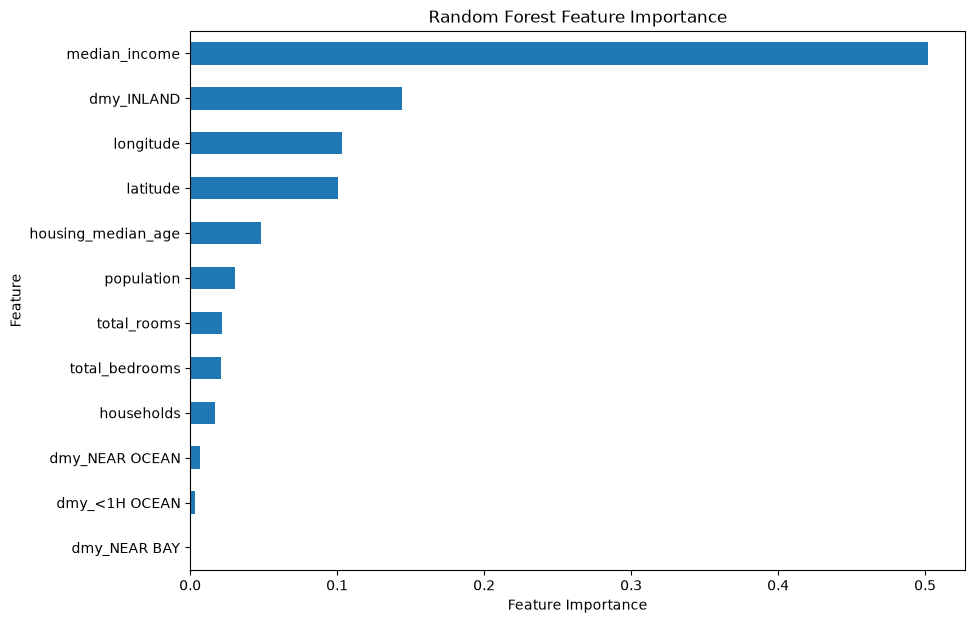

In [59]:
importance.sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()